In [2]:
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

data_folder = project_root / "data"
data_folder.mkdir(exist_ok=True)

data = {
    "trial_id": [1, 2],
    "date": ["2026-06-21", "2026-06-21"],
    "condition": ["calm", "stress"],
    "resting_hr": [75, 75],
    "post_exercise_hr": [141, 144],
    "hr_60s": [83, 86],
    "completion_time": ["N/A", "2:17.46"],
    "side_notes": [
        "Approx 2h after hitting with Richard, 8 hours of sleep, 0 mistakes made while skipping",
        "Approx 2h after hitting with Richard, 8 hours of sleep, 7 mistakes made while skipping"
    ]
}

df = pd.DataFrame(data)

df["hrr"] = df["post_exercise_hr"] - df["hr_60s"]

df = df[
    [
        "trial_id",
        "date",
        "condition",
        "resting_hr",
        "post_exercise_hr",
        "hr_60s",
        "hrr",
        "completion_time",
        "side_notes"
    ]
]

df.to_csv(data_folder / "research_data.csv", index=False)

df

,trial_id,date,condition,resting_hr,post_exercise_hr,hr_60s,hrr,completion_time,side_notes
0,1,2026-06-21,calm,75,141,83,58,N/A,"Approx 2h after hitting with Richard, 8 hours ..."
1,2,2026-06-21,stress,75,144,86,58,2:17.46,"Approx 2h after hitting with Richard, 8 hours ..."


In [3]:
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_path = project_root / "data" / "research_data.csv"

df = pd.read_csv(data_path)

df

,trial_id,date,condition,resting_hr,post_exercise_hr,hr_60s,hrr,completion_time,side_notes
0,1,2026-06-21,calm,75,141,83,58,NaN,"Approx 2h after hitting with Richard, 8 hours ..."
1,2,2026-06-21,stress,75,144,86,58,2:17.46,"Approx 2h after hitting with Richard, 8 hours ..."


In [4]:
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_path = project_root / "data" / "research_data.csv"

df = pd.read_csv(data_path, keep_default_na=False)

# Add the two new scale columns if they do not already exist
if "exertion_scale" not in df.columns:
    df["exertion_scale"] = ""

if "stress_scale" not in df.columns:
    df["stress_scale"] = ""

# Add scale values for trials 1-4
scale_values = {
    1: {"exertion_scale": 6, "stress_scale": 3},
    2: {"exertion_scale": 6, "stress_scale": 6},
    3: {"exertion_scale": 5, "stress_scale": 3},
    4: {"exertion_scale": 6, "stress_scale": 6},
}

for trial_id, values in scale_values.items():
    for column, value in values.items():
        df.loc[df["trial_id"] == trial_id, column] = value

# New trial rows
new_rows = pd.DataFrame([
    {
        "trial_id": 3,
        "date": "2026-06-24",
        "condition": "calm",
        "resting_hr": 75,
        "post_exercise_hr": 143,
        "hr_60s": 88,
        "hrr": 55,
        "completion_time": "N/A",
        "side_notes": "8 hours of sleep; timer shut off at 50 seconds remaining, had to guess; approximately 3 hours and 30 minutes after 30 minute HIIT workout; 3 mistakes were made while skipping",
        "exertion_scale": 5,
        "stress_scale": 3
    },
    {
        "trial_id": 4,
        "date": "2026-06-24",
        "condition": "stress",
        "resting_hr": 75,
        "post_exercise_hr": 153,
        "hr_60s": 91,
        "hrr": 62,
        "completion_time": "2:03.30",
        "side_notes": "8 hours of sleep; approximately 3 hours and 30 minutes after 30 minute HIIT workout; 4 mistakes were made while skipping; made a mistake when doing serial sevens test - did not end at 4, ended on 6",
        "exertion_scale": 6,
        "stress_scale": 6
    }
])

# Only add trials 3 and 4 if they are not already in the table
new_rows = new_rows[~new_rows["trial_id"].isin(df["trial_id"])]

df = pd.concat([df, new_rows], ignore_index=True)

# Recalculate HRR just to make sure it is correct
df["hrr"] = df["post_exercise_hr"] - df["hr_60s"]

df.to_csv(data_path, index=False)

df

TypeError: Invalid value '6' for dtype 'str'. Value should be a string or missing value, got 'int' instead.

In [5]:
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_path = project_root / "data" / "research_data.csv"

df = pd.read_csv(data_path, keep_default_na=False)

# Add the two new columns
if "exertion_scale" not in df.columns:
    df["exertion_scale"] = ""

if "stress_scale" not in df.columns:
    df["stress_scale"] = ""

# Add scale values for the existing trials
df.loc[df["trial_id"] == 1, "exertion_scale"] = 6
df.loc[df["trial_id"] == 1, "stress_scale"] = 3

df.loc[df["trial_id"] == 2, "exertion_scale"] = 6
df.loc[df["trial_id"] == 2, "stress_scale"] = 6

# Remove trial 3 and 4 if they already exist, so we do not accidentally duplicate them
df = df[~df["trial_id"].isin([3, 4])]

# Add trial 3 and trial 4
new_rows = pd.DataFrame([
    {
        "trial_id": 3,
        "date": "2026-06-24",
        "condition": "calm",
        "resting_hr": 75,
        "post_exercise_hr": 143,
        "hr_60s": 88,
        "hrr": 55,
        "completion_time": "N/A",
        "side_notes": "8 hours of sleep; timer shut off at 50 seconds remaining, had to guess; approximately 3 hours and 30 minutes after 30 minute HIIT workout; 3 mistakes were made while skipping",
        "exertion_scale": 5,
        "stress_scale": 3
    },
    {
        "trial_id": 4,
        "date": "2026-06-24",
        "condition": "stress",
        "resting_hr": 75,
        "post_exercise_hr": 153,
        "hr_60s": 91,
        "hrr": 62,
        "completion_time": "2:03.30",
        "side_notes": "8 hours of sleep; approximately 3 hours and 30 minutes after 30 minute HIIT workout; 4 mistakes were made while skipping; made a mistake when doing serial sevens test - did not end at 4, ended on 6",
        "exertion_scale": 6,
        "stress_scale": 6
    }
])

df = pd.concat([df, new_rows], ignore_index=True)

# Recalculate heart-rate recovery
df["hrr"] = df["post_exercise_hr"] - df["hr_60s"]

# Save the updated table
df.to_csv(data_path, index=False)

df

TypeError: Invalid value '6' for dtype 'str'. Value should be a string or missing value, got 'int' instead.

In [6]:
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_path = project_root / "data" / "research_data.csv"

df = pd.read_csv(data_path, keep_default_na=False)

# Add the two new columns if they do not already exist
if "exertion_scale" not in df.columns:
    df["exertion_scale"] = pd.NA

if "stress_scale" not in df.columns:
    df["stress_scale"] = pd.NA

# Make sure these columns can hold numbers
df["exertion_scale"] = pd.to_numeric(df["exertion_scale"], errors="coerce").astype("Int64")
df["stress_scale"] = pd.to_numeric(df["stress_scale"], errors="coerce").astype("Int64")

# Add scale values for existing trials 1 and 2
df.loc[df["trial_id"] == 1, "exertion_scale"] = 6
df.loc[df["trial_id"] == 1, "stress_scale"] = 3

df.loc[df["trial_id"] == 2, "exertion_scale"] = 5.5
df.loc[df["trial_id"] == 2, "stress_scale"] = 6.5

# Remove trial 3 and 4 if they already exist, so we do not duplicate them
df = df[~df["trial_id"].isin([3, 4])]

# Add trial 3 and trial 4
new_rows = pd.DataFrame([
    {
        "trial_id": 3,
        "date": "2026-06-24",
        "condition": "calm",
        "resting_hr": 75,
        "post_exercise_hr": 143,
        "hr_60s": 88,
        "hrr": 55,
        "completion_time": "N/A",
        "side_notes": "8 hours of sleep; timer shut off at 50 seconds remaining, had to guess; approximately 3 hours and 30 minutes after 30 minute HIIT workout; 3 mistakes were made while skipping",
        "exertion_scale": 5.5,
        "stress_scale": 3
    },
    {
        "trial_id": 4,
        "date": "2026-06-24",
        "condition": "stress",
        "resting_hr": 75,
        "post_exercise_hr": 153,
        "hr_60s": 91,
        "hrr": 62,
        "completion_time": "2:03.30",
        "side_notes": "8 hours of sleep; approximately 3 hours and 30 minutes after 30 minute HIIT workout; 4 mistakes were made while skipping; made a mistake when doing serial sevens test - did not end at 4, ended on 6",
        "exertion_scale": 6.5,
        "stress_scale": 6.5
    }
])

df = pd.concat([df, new_rows], ignore_index=True)

# Recalculate HRR
df["hrr"] = df["post_exercise_hr"] - df["hr_60s"]

# Save the updated table
df.to_csv(data_path, index=False)

df

TypeError: Invalid value '5.5' for dtype 'Int64'

In [7]:
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_path = project_root / "data" / "research_data.csv"

df = pd.read_csv(data_path, keep_default_na=False)

# Make sure trial_id is treated as a number
df["trial_id"] = pd.to_numeric(df["trial_id"], errors="coerce").astype("Int64")

# Add the two new columns if they do not already exist
if "exertion_scale" not in df.columns:
    df["exertion_scale"] = pd.NA

if "stress_scale" not in df.columns:
    df["stress_scale"] = pd.NA

# These columns need to allow decimals, so use Float64, not Int64
df["exertion_scale"] = pd.to_numeric(df["exertion_scale"], errors="coerce").astype("Float64")
df["stress_scale"] = pd.to_numeric(df["stress_scale"], errors="coerce").astype("Float64")

# Add scale values for existing trials 1 and 2
df.loc[df["trial_id"] == 1, "exertion_scale"] = 6
df.loc[df["trial_id"] == 1, "stress_scale"] = 3

df.loc[df["trial_id"] == 2, "exertion_scale"] = 5.5
df.loc[df["trial_id"] == 2, "stress_scale"] = 6.5

# Remove trials 3 and 4 if they already exist, so we do not duplicate them
df = df[~df["trial_id"].isin([3, 4])]

# Add trials 3 and 4
new_rows = pd.DataFrame([
    {
        "trial_id": 3,
        "date": "2026-06-24",
        "condition": "calm",
        "resting_hr": 75,
        "post_exercise_hr": 143,
        "hr_60s": 88,
        "hrr": 55,
        "completion_time": "N/A",
        "side_notes": "8 hours of sleep; timer shut off at 50 seconds remaining, had to guess; approximately 3 hours and 30 minutes after 30 minute HIIT workout; 3 mistakes were made while skipping",
        "exertion_scale": 5.5,
        "stress_scale": 3
    },
    {
        "trial_id": 4,
        "date": "2026-06-24",
        "condition": "stress",
        "resting_hr": 75,
        "post_exercise_hr": 153,
        "hr_60s": 91,
        "hrr": 62,
        "completion_time": "2:03.30",
        "side_notes": "8 hours of sleep; approximately 3 hours and 30 minutes after 30 minute HIIT workout; 4 mistakes were made while skipping; made a mistake when doing serial sevens test - did not end at 4, ended on 6",
        "exertion_scale": 6.5,
        "stress_scale": 6.5
    }
])

df = pd.concat([df, new_rows], ignore_index=True)

# Make sure heart rate columns are numbers
df["post_exercise_hr"] = pd.to_numeric(df["post_exercise_hr"], errors="coerce")
df["hr_60s"] = pd.to_numeric(df["hr_60s"], errors="coerce")

# Recalculate HRR
df["hrr"] = df["post_exercise_hr"] - df["hr_60s"]

# Save the updated table
df.to_csv(data_path, index=False)

df

,trial_id,date,condition,resting_hr,post_exercise_hr,hr_60s,hrr,completion_time,side_notes,exertion_scale,stress_scale
0,1,2026-06-21,calm,75,141,83,58,N/A,"Approx 2h after hitting with Richard, 8 hours ...",6.0,3.0
1,2,2026-06-21,stress,75,144,86,58,2:17.46,"Approx 2h after hitting with Richard, 8 hours ...",5.5,6.5
2,3,2026-06-24,calm,75,143,88,55,N/A,8 hours of sleep; timer shut off at 50 seconds...,5.5,3.0
3,4,2026-06-24,stress,75,153,91,62,2:03.30,8 hours of sleep; approximately 3 hours and 30...,6.5,6.5


In [8]:
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_path = project_root / "data" / "research_data.csv"

df = pd.read_csv(data_path, keep_default_na=False)

# Make sure trial_id is numeric
df["trial_id"] = pd.to_numeric(df["trial_id"], errors="coerce").astype("Int64")

# Make sure the two scale columns exist
if "exertion_scale" not in df.columns:
    df["exertion_scale"] = pd.NA

if "stress_scale" not in df.columns:
    df["stress_scale"] = pd.NA

# These columns allow decimals like 5.5 or 6.5
df["exertion_scale"] = pd.to_numeric(df["exertion_scale"], errors="coerce").astype("Float64")
df["stress_scale"] = pd.to_numeric(df["stress_scale"], errors="coerce").astype("Float64")

# Remove trials 5 and 6 if they already exist, so we do not accidentally duplicate them
df = df[~df["trial_id"].isin([5, 6])]

new_rows = pd.DataFrame([
    {
        "trial_id": 5,
        "date": "2026-06-25",
        "condition": "calm",
        "resting_hr": 70,
        "post_exercise_hr": 135,      # TODO: replace this
        "hr_60s": 81,                # TODO: replace this
        "hrr": 54,
        "completion_time": "N/A",
        "side_notes": "About 8 hours sleep (maybe 8.5?); 2 mistakes were made while skipping; sore in glutes from yesterday's HIIT workout; no workout or physcial activity was done today",           # TODO: replace this
        "exertion_scale": 4.5,        # TODO: replace this
        "stress_scale": 2           # TODO: replace this
    },
    {
        "trial_id": 6,
        "date": "2026-06-25",
        "condition": "stress",
        "resting_hr": 70,
        "post_exercise_hr": 134,      # TODO: replace this
        "hr_60s": 76,                # TODO: replace this
        "hrr": 64,
        "completion_time": "1:30.76",      # TODO: replace this
        "side_notes": "About 8 hours sleep (maybe 8.5?); 5 mistakes were made while skipping; had mild cramp after making 3 mistakes at 1:30; watch took a couple of seconds after skipping to give heart rate; sore in glutes from yesterday's HIIT workout; no workout or physcial activity was done today",           # TODO: replace this
        "exertion_scale": 5,        # TODO: replace this
        "stress_scale": 5.5           # TODO: replace this
    }
])

df = pd.concat([df, new_rows], ignore_index=True)

# Make sure HR columns are numbers
df["post_exercise_hr"] = pd.to_numeric(df["post_exercise_hr"], errors="coerce")
df["hr_60s"] = pd.to_numeric(df["hr_60s"], errors="coerce")

# Calculate HRR automatically
df["hrr"] = df["post_exercise_hr"] - df["hr_60s"]

# Save the updated table
df.to_csv(data_path, index=False)

df

,trial_id,date,condition,resting_hr,post_exercise_hr,hr_60s,hrr,completion_time,side_notes,exertion_scale,stress_scale
0,1,2026-06-21,calm,75,141,83,58,N/A,"Approx 2h after hitting with Richard, 8 hours ...",6.0,3.0
1,2,2026-06-21,stress,75,144,86,58,2:17.46,"Approx 2h after hitting with Richard, 8 hours ...",5.5,6.5
2,3,2026-06-24,calm,75,143,88,55,N/A,8 hours of sleep; timer shut off at 50 seconds...,5.5,3.0
3,4,2026-06-24,stress,75,153,91,62,2:03.30,8 hours of sleep; approximately 3 hours and 30...,6.5,6.5
4,5,2026-06-25,calm,70,135,81,54,N/A,About 8 hours sleep (maybe 8.5?); 2 mistakes w...,4.5,2.0
5,6,2026-06-25,stress,70,134,76,58,1:30.76,About 8 hours sleep (maybe 8.5?); 5 mistakes w...,5.0,5.5


In [1]:
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

df = pd.read_csv(project_root / "data" / "hrr_data.csv")

df

,trial_id,date,condition,pre_hr,post_hr,hr_60s,hrr
0,1,2026-06-21,calm,75,141,83,58
1,2,2026-06-21,stress,75,144,86,58
2,3,2026-06-24,calm,75,143,88,55
3,4,2026-06-24,stress,75,153,91,62
4,5,2026-06-25,calm,70,135,81,54
5,6,2026-06-25,stress,70,134,76,58


In [2]:
df.describe()

,trial_id,pre_hr,post_hr,hr_60s,hrr
count,6.000000,6.000000,6.000000,6.000000,6.000000
mean,3.500000,73.333333,141.666667,84.166667,57.500000
std,1.870829,2.581989,6.918574,5.344779,2.810694
min,1.000000,70.000000,134.000000,76.000000,54.000000
25%,2.250000,71.250000,136.500000,81.500000,55.750000
50%,3.500000,75.000000,142.000000,84.500000,58.000000
75%,4.750000,75.000000,143.750000,87.500000,58.000000
max,6.000000,75.000000,153.000000,91.000000,62.000000


Matplotlib is building the font cache; this may take a moment.


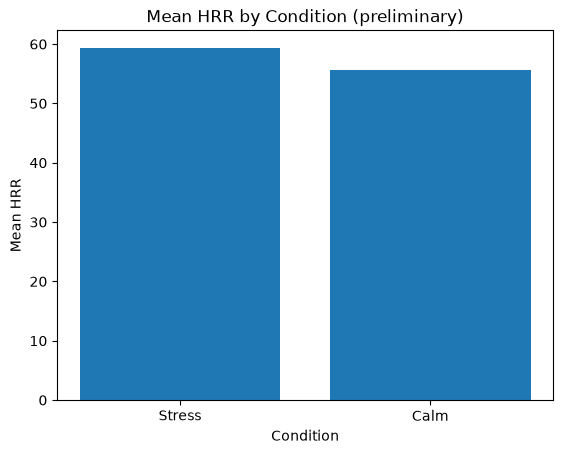

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

data_path = project_root / "data" / "hrr_data.csv"
figures_folder = project_root / "figures"
figures_folder.mkdir(exist_ok=True)

df = pd.read_csv(data_path)

stress_mean = df[df["condition"] == "stress"]["hrr"].mean()
calm_mean = df[df["condition"] == "calm"]["hrr"].mean()

plt.figure()
plt.bar(
    ["Stress", "Calm"],
    [stress_mean, calm_mean]
)

plt.xlabel("Condition")
plt.ylabel("Mean HRR")
plt.title("Mean HRR by Condition (preliminary)")

plt.savefig(figures_folder / "test_chart.png", dpi=300, bbox_inches="tight")
plt.show()

,trial_id,date,condition,pre_hr,post_hr,hr_60s,hrr,exertion_scale,stress_scale,side_notes
0,1,2026-06-21,calm,75,141,83,58,6.0,3.0,Approximately 2 hours after tennis; sore arm f...
1,2,2026-06-21,stress,75,144,86,58,5.5,6.5,Approximately 2 hours after tennis; sore arms ...
2,3,2026-06-24,calm,75,143,88,55,5.5,3.0,8 hours of sleep; timer shut off at 50 seconds...
3,4,2026-06-24,stress,75,153,91,62,6.5,6.5,8 hours of sleep; approximately 3 hours and 30...
4,5,2026-06-25,calm,70,135,81,54,4.5,2.0,About 8 hours sleep maybe 8.5; 2 mistakes were...
5,6,2026-06-25,stress,70,134,76,58,5.0,5.5,About 8 hours sleep maybe 8.5; 5 mistakes were...
6,7,2026-06-28,calm,75,147,104,43,5.5,2.5,About 8 hours of sleep; just over 1 hour after...
7,8,2026-06-28,stress,73,149,103,46,0.0,5.5,About 8 hours of sleep; just over 1 hour after...


,trial_id,pre_hr,post_hr,hr_60s,hrr,exertion_scale,stress_scale
count,8.0,8.000000,8.000000,8.000000,8.000000,8.0,8.0
mean,4.5,73.500000,143.250000,89.000000,54.250000,4.8125,4.3125
std,2.44949,2.267787,6.562883,10.028531,6.519202,2.034304,1.869635
min,1.0,70.000000,134.000000,76.000000,43.000000,0.0,2.0
25%,2.75,72.250000,139.500000,82.500000,52.000000,4.875,2.875
50%,4.5,75.000000,143.500000,87.000000,56.500000,5.5,4.25
75%,6.25,75.000000,147.500000,94.000000,58.000000,5.625,5.75
max,8.0,75.000000,153.000000,104.000000,62.000000,6.5,6.5


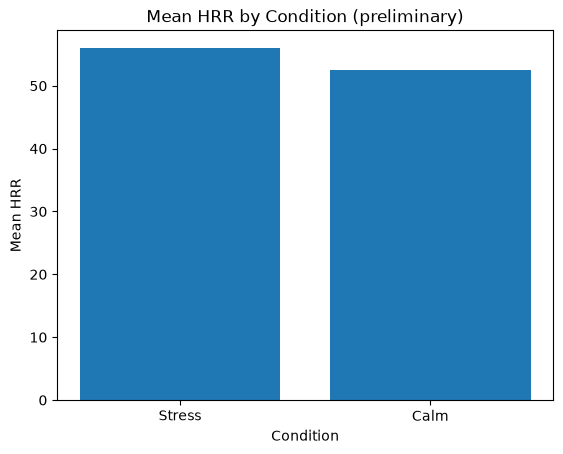

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

data_path = project_root / "data" / "hrr_data.csv"
figures_folder = project_root / "figures"
figures_folder.mkdir(exist_ok=True)

df = pd.read_csv(data_path)

df["trial_id"] = pd.to_numeric(df["trial_id"], errors="coerce").astype("Int64")

# Add scale/note columns if missing
if "exertion_scale" not in df.columns:
    df["exertion_scale"] = pd.NA

if "stress_scale" not in df.columns:
    df["stress_scale"] = pd.NA

if "side_notes" not in df.columns:
    df["side_notes"] = ""

# Allow decimals like 5.5
df["exertion_scale"] = pd.to_numeric(df["exertion_scale"], errors="coerce").astype("Float64")
df["stress_scale"] = pd.to_numeric(df["stress_scale"], errors="coerce").astype("Float64")

# Remove trials 7 and 8 if they already exist
df = df[~df["trial_id"].isin([7, 8])]

new_rows = pd.DataFrame([
    {
        "trial_id": 7,
        "date": "2026-06-28",
        "condition": "calm",
        "pre_hr": 75,
        "post_hr": 147,
        "hr_60s": 104,
        "hrr": 43,
        "exertion_scale": 5.5,
        "stress_scale": 2.5,
        "side_notes": "About 8 hours of sleep; just over 1 hour after 1.5 hours of tennis; 0 mistakes were made while skipping"
    },
    {
        "trial_id": 8,
        "date": "2026-06-28",
        "condition": "stress",
        "pre_hr": 73,
        "post_hr": 149,
        "hr_60s": 103,
        "hrr": 46,
        "exertion_scale": 0,   # replace this with the real Trial 8 exertion value
        "stress_scale": 5.5,
        "side_notes": "About 8 hours of sleep; just over 1 hour after 1.5 hours of tennis; 0 mistakes were made while skipping"
    }
])

df = pd.concat([df, new_rows], ignore_index=True)

# Recalculate HRR
df["hrr"] = df["post_hr"] - df["hr_60s"]

df.to_csv(data_path, index=False)

display(df)
display(df.describe())

stress_mean = df[df["condition"] == "stress"]["hrr"].mean()
calm_mean = df[df["condition"] == "calm"]["hrr"].mean()

plt.figure()
plt.bar(["Stress", "Calm"], [stress_mean, calm_mean])
plt.xlabel("Condition")
plt.ylabel("Mean HRR")
plt.title("Mean HRR by Condition (preliminary)")
plt.savefig(figures_folder / "test_chart.png", dpi=300, bbox_inches="tight")
plt.show()

In [1]:
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_path = project_root / "data" / "hrr_data.csv"

df = pd.read_csv(data_path, keep_default_na=False)

# Make sure all needed columns exist
needed_columns = [
    "trial_id",
    "date",
    "condition",
    "pre_hr",
    "post_hr",
    "hr_60s",
    "hrr",
    "exertion_scale",
    "stress_scale",
    "side_notes"
]

for column in needed_columns:
    if column not in df.columns:
        df[column] = ""

# Make trial_id numeric so we can safely remove/reinsert trials 9 and 10
df["trial_id"] = pd.to_numeric(df["trial_id"], errors="coerce").astype("Int64")

# Remove trials 9 and 10 if they already exist, so we do not duplicate them
df = df[~df["trial_id"].isin([9, 10])]

# Add trials 9 and 10
new_rows = pd.DataFrame([
    {
        "trial_id": 9,
        "date": "2026-07-01",
        "condition": "calm",
        "pre_hr": 74,
        "post_hr": 140,
        "hr_60s": 86,
        "hrr": 54,
        "exertion_scale": 6.0,
        "stress_scale": 3.0,
        "side_notes": "About 8 hours of sleep; played 1 hour of tennis about 5 hours ago; extremely warm and humid weather about 36°C, feels like 46°C; 6 mistakes were made while skipping"
    },
    {
        "trial_id": 10,
        "date": "2026-07-01",
        "condition": "stress",
        "pre_hr": 74,
        "post_hr": 141,
        "hr_60s": 88,
        "hrr": 53,
        "exertion_scale": 6.5,
        "stress_scale": 5.0,
        "side_notes": "About 8 hours of sleep; played 1 hour of tennis about 5 hours ago; extremely warm and humid weather about 36°C, feels like 46°C; 4 mistakes were made while skipping"
    }
])

df = pd.concat([df, new_rows], ignore_index=True)

# Convert numeric columns
number_columns = [
    "pre_hr",
    "post_hr",
    "hr_60s",
    "hrr",
    "exertion_scale",
    "stress_scale"
]

for column in number_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Recalculate HRR to make sure it is correct
df["hrr"] = df["post_hr"] - df["hr_60s"]

# Sort by trial number
df = df.sort_values("trial_id").reset_index(drop=True)

# Save updated CSV
df.to_csv(data_path, index=False)

# Show updated dataset
display(df)

# Run the required statistics
condition_means = df.groupby("condition")["hrr"].mean()

display(condition_means)

print("Mean HRR by condition:")
print(condition_means)

,trial_id,date,condition,pre_hr,post_hr,hr_60s,hrr,exertion_scale,stress_scale,side_notes
0,1,2026-06-21,calm,75,141,83,58,6.0,3.0,Approximately 2 hours after tennis; sore arm f...
1,2,2026-06-21,stress,75,144,86,58,5.5,6.5,Approximately 2 hours after tennis; sore arms ...
2,3,2026-06-24,calm,75,143,88,55,5.5,3.0,8 hours of sleep; timer shut off at 50 seconds...
3,4,2026-06-24,stress,75,153,91,62,6.5,6.5,8 hours of sleep; approximately 3 hours and 30...
4,5,2026-06-25,calm,70,135,81,54,4.5,2.0,About 8 hours sleep maybe 8.5; 2 mistakes were...
5,6,2026-06-25,stress,70,134,76,58,5.0,5.5,About 8 hours sleep maybe 8.5; 5 mistakes were...
6,7,2026-06-28,calm,75,147,104,43,5.5,2.5,About 8 hours of sleep; just over 1 hour after...
7,8,2026-06-28,stress,73,149,103,46,0.0,5.5,About 8 hours of sleep; just over 1 hour after...
8,9,2026-07-01,calm,74,140,86,54,6.0,3.0,About 8 hours of sleep; played 1 hour of tenni...
9,10,2026-07-01,stress,74,141,88,53,6.5,5.0,About 8 hours of sleep; played 1 hour of tenni...


condition
calm      52.8
stress    55.4
Name: hrr, dtype: float64

Mean HRR by condition:
condition
calm      52.8
stress    55.4
Name: hrr, dtype: float64


The mean HRR for the calm condition is 52.8. The mean HRR for the stress condition is 55.4. These values show the average HRR for each condition across the 10 trials collected so far.

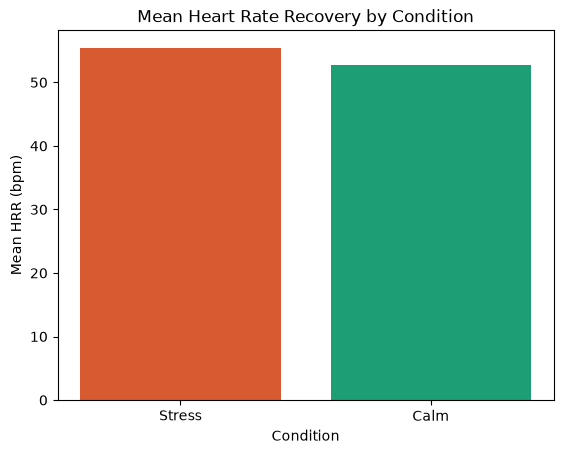

Stress mean HRR: 55.4
Calm mean HRR: 52.8


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

data_path = project_root / "data" / "hrr_data.csv"
figures_folder = project_root / "figures"
figures_folder.mkdir(exist_ok=True)

df = pd.read_csv(data_path)

df["hrr"] = pd.to_numeric(df["hrr"], errors="coerce")

stress_hrr = df[df["condition"] == "stress"]["hrr"]
calm_hrr = df[df["condition"] == "calm"]["hrr"]

plt.figure()

plt.bar(
    ["Stress", "Calm"],
    [stress_hrr.mean(), calm_hrr.mean()],
    color=["#D85A30", "#1D9E75"]
)

plt.ylabel("Mean HRR (bpm)")
plt.xlabel("Condition")
plt.title("Mean Heart Rate Recovery by Condition")

plt.savefig(figures_folder / "graph1_draft.png", dpi=150, bbox_inches="tight")

plt.show()

print("Stress mean HRR:", stress_hrr.mean())
print("Calm mean HRR:", calm_hrr.mean())

Full dataset:


,trial_id,date,condition,pre_hr,post_hr,hr_60s,hrr,exertion_scale,stress_scale,side_notes
0,1,2026-06-21,calm,75,141,83,58,6.0,3.0,Approximately 2 hours after tennis; sore arm f...
1,2,2026-06-21,stress,75,144,86,58,5.5,6.5,Approximately 2 hours after tennis; sore arms ...
2,3,2026-06-24,calm,75,143,88,55,5.5,3.0,8 hours of sleep; timer shut off at 50 seconds...
3,4,2026-06-24,stress,75,153,91,62,6.5,6.5,8 hours of sleep; approximately 3 hours and 30...
4,5,2026-06-25,calm,70,135,81,54,4.5,2.0,About 8 hours sleep maybe 8.5; 2 mistakes were...
5,6,2026-06-25,stress,70,134,76,58,5.0,5.5,About 8 hours sleep maybe 8.5; 5 mistakes were...
6,7,2026-06-28,calm,75,147,104,43,5.5,2.5,About 8 hours of sleep; just over 1 hour after...
7,8,2026-06-28,stress,73,149,103,46,0.0,5.5,About 8 hours of sleep; just over 1 hour after...
8,9,2026-07-01,calm,74,140,86,54,6.0,3.0,About 8 hours of sleep; played 1 hour of tenni...
9,10,2026-07-01,stress,74,141,88,53,6.5,5.0,About 8 hours of sleep; played 1 hour of tenni...


HRR values sorted from lowest to highest:


,trial_id,condition,hrr,side_notes
10,11,calm,34,About 8 hours of sleep; did fitness about 5 ho...
6,7,calm,43,About 8 hours of sleep; just over 1 hour after...
7,8,stress,46,About 8 hours of sleep; just over 1 hour after...
11,12,stress,47,About 8 hours of sleep; did fitness about 5 ho...
9,10,stress,53,About 8 hours of sleep; played 1 hour of tenni...
8,9,calm,54,About 8 hours of sleep; played 1 hour of tenni...
4,5,calm,54,About 8 hours sleep maybe 8.5; 2 mistakes were...
2,3,calm,55,8 hours of sleep; timer shut off at 50 seconds...
1,2,stress,58,Approximately 2 hours after tennis; sore arms ...
5,6,stress,58,About 8 hours sleep maybe 8.5; 5 mistakes were...


Outlier check:
Q1: 46.75
Q3: 58.0
IQR: 11.25
Lower bound: 29.875
Upper bound: 74.875
No HRR values were flagged as outliers using the 1.5 × IQR rule.


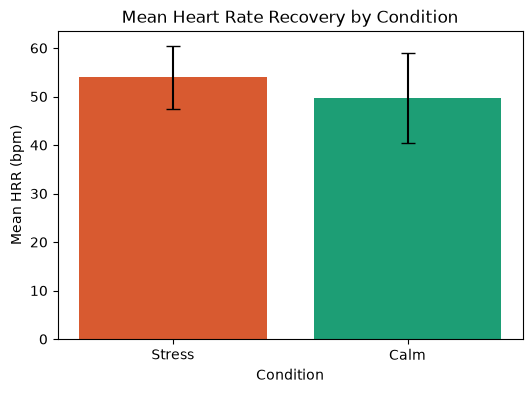

Mean HRR values:
Stress: 54.0
Calm: 49.666666666666664
Standard deviations:
Stress: 6.48074069840786
Calm: 9.223159256278008


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

data_path = project_root / "data" / "hrr_data.csv"
figures_folder = project_root / "figures"
figures_folder.mkdir(exist_ok=True)

df = pd.read_csv(data_path, keep_default_na=False)

needed_columns = [
    "trial_id",
    "date",
    "condition",
    "pre_hr",
    "post_hr",
    "hr_60s",
    "hrr",
    "exertion_scale",
    "stress_scale",
    "side_notes"
]

for column in needed_columns:
    if column not in df.columns:
        df[column] = ""

df["trial_id"] = pd.to_numeric(df["trial_id"], errors="coerce").astype("Int64")

df = df[~df["trial_id"].isin([11, 12])]

new_rows = pd.DataFrame([
    {
        "trial_id": 11,
        "date": "2026-07-04",
        "condition": "calm",
        "pre_hr": 74,
        "post_hr": 121,
        "hr_60s": 87,
        "hrr": 34,
        "exertion_scale": 5.0,
        "stress_scale": 3.5,
        "side_notes": "About 8 hours of sleep; did fitness about 5 hours ago; 2 mistakes were made while skipping"
    },
    {
        "trial_id": 12,
        "date": "2026-07-04",
        "condition": "stress",
        "pre_hr": 75,
        "post_hr": 137,
        "hr_60s": 90,
        "hrr": 47,
        "exertion_scale": 6.0,
        "stress_scale": 6.5,
        "side_notes": "About 8 hours of sleep; did fitness about 5 hours ago; 6 mistakes were made while skipping"
    }
])

df = pd.concat([df, new_rows], ignore_index=True)

number_columns = [
    "pre_hr",
    "post_hr",
    "hr_60s",
    "hrr",
    "exertion_scale",
    "stress_scale"
]

for column in number_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df["hrr"] = df["post_hr"] - df["hr_60s"]

df = df.sort_values("trial_id").reset_index(drop=True)

df.to_csv(data_path, index=False)

print("Full dataset:")
display(df)

print("HRR values sorted from lowest to highest:")
display(df[["trial_id", "condition", "hrr", "side_notes"]].sort_values("hrr"))

q1 = df["hrr"].quantile(0.25)
q3 = df["hrr"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

potential_outliers = df[(df["hrr"] < lower_bound) | (df["hrr"] > upper_bound)]

print("Outlier check:")
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

if len(potential_outliers) == 0:
    print("No HRR values were flagged as outliers using the 1.5 × IQR rule.")
else:
    print("Potential outliers:")
    display(potential_outliers[["trial_id", "condition", "hrr", "side_notes"]])

stress_hrr = df[df["condition"] == "stress"]["hrr"]
calm_hrr = df[df["condition"] == "calm"]["hrr"]

means = [stress_hrr.mean(), calm_hrr.mean()]
stds = [stress_hrr.std(), calm_hrr.std()]

plt.figure(figsize=(6, 4))

plt.bar(
    ["Stress", "Calm"],
    means,
    yerr=stds,
    capsize=5,
    color=["#D85A30", "#1D9E75"]
)

plt.ylabel("Mean HRR (bpm)")
plt.xlabel("Condition")
plt.title("Mean Heart Rate Recovery by Condition")
plt.savefig(figures_folder / "graph1_draft.png", dpi=150, bbox_inches="tight")
plt.show()

print("Mean HRR values:")
print("Stress:", stress_hrr.mean())
print("Calm:", calm_hrr.mean())

print("Standard deviations:")
print("Stress:", stress_hrr.std())
print("Calm:", calm_hrr.std())

After adding trials 11 and 12, I checked the full dataset for possible HRR outliers. Trial 11 has the lowest HRR value so far, with an HRR of 34 bpm. I will keep this data point because there is no documented protocol reason to delete it, but I will note it as a possible point to discuss in the limitations section. The error bars on Graph 1 show the spread of HRR values within each condition.

Updated dataset:


,trial_id,date,condition,pre_hr,post_hr,hr_60s,hrr,exertion_scale,stress_scale,side_notes
0,1,2026-06-21,calm,75,141,83,58,6.0,3.0,Approximately 2 hours after tennis; sore arm f...
1,2,2026-06-21,stress,75,144,86,58,5.5,6.5,Approximately 2 hours after tennis; sore arms ...
2,3,2026-06-24,calm,75,143,88,55,5.5,3.0,8 hours of sleep; timer shut off at 50 seconds...
3,4,2026-06-24,stress,75,153,91,62,6.5,6.5,8 hours of sleep; approximately 3 hours and 30...
4,5,2026-06-25,calm,70,135,81,54,4.5,2.0,About 8 hours sleep maybe 8.5; 2 mistakes were...
5,6,2026-06-25,stress,70,134,76,58,5.0,5.5,About 8 hours sleep maybe 8.5; 5 mistakes were...
6,7,2026-06-28,calm,75,147,104,43,5.5,2.5,About 8 hours of sleep; just over 1 hour after...
7,8,2026-06-28,stress,73,149,103,46,0.0,5.5,About 8 hours of sleep; just over 1 hour after...
8,9,2026-07-01,calm,74,140,86,54,6.0,3.0,About 8 hours of sleep; played 1 hour of tenni...
9,10,2026-07-01,stress,74,141,88,53,6.5,5.0,About 8 hours of sleep; played 1 hour of tenni...


Mean HRR by condition:


condition
calm      50.000000
stress    54.285714
Name: hrr, dtype: float64

HRR values sorted from lowest to highest:


,trial_id,condition,hrr,side_notes
10,11,calm,34,About 8 hours of sleep; did fitness about 5 ho...
6,7,calm,43,About 8 hours of sleep; just over 1 hour after...
7,8,stress,46,About 8 hours of sleep; just over 1 hour after...
11,12,stress,47,About 8 hours of sleep; did fitness about 5 ho...
12,13,calm,52,About 8 hours of sleep; changing start times o...
9,10,stress,53,About 8 hours of sleep; played 1 hour of tenni...
4,5,calm,54,About 8 hours sleep maybe 8.5; 2 mistakes were...
8,9,calm,54,About 8 hours of sleep; played 1 hour of tenni...
2,3,calm,55,8 hours of sleep; timer shut off at 50 seconds...
13,14,stress,56,About 8 hours of sleep; changing start times o...


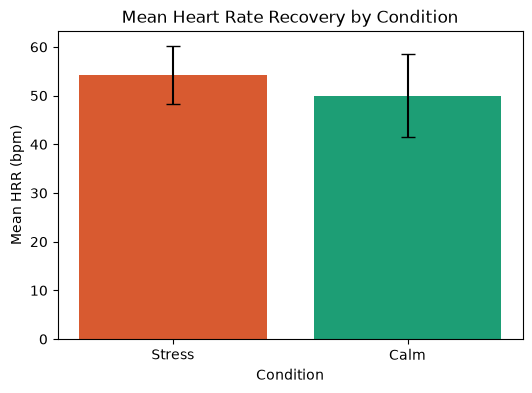

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

data_path = project_root / "data" / "hrr_data.csv"
figures_folder = project_root / "figures"
figures_folder.mkdir(exist_ok=True)

df = pd.read_csv(data_path, keep_default_na=False)

needed_columns = [
    "trial_id",
    "date",
    "condition",
    "pre_hr",
    "post_hr",
    "hr_60s",
    "hrr",
    "exertion_scale",
    "stress_scale",
    "side_notes"
]

for column in needed_columns:
    if column not in df.columns:
        df[column] = ""

df["trial_id"] = pd.to_numeric(df["trial_id"], errors="coerce").astype("Int64")

# Remove trials 13 and 14 if they already exist, so we do not duplicate them
df = df[~df["trial_id"].isin([13, 14])]

new_rows = pd.DataFrame([
    {
        "trial_id": 13,
        "date": "2026-07-07",
        "condition": "calm",
        "pre_hr": 68,
        "post_hr": 136,
        "hr_60s": 84,
        "hrr": 52,
        "exertion_scale": 4.5,
        "stress_scale": 3.0,
        "side_notes": "About 8 hours of sleep; changing start times of trials due to schedule change; no physical exercise done today outside of walking; 5 mistakes were made while skipping"
    },
    {
        "trial_id": 14,
        "date": "2026-07-07",
        "condition": "stress",
        "pre_hr": 68,
        "post_hr": 140,
        "hr_60s": 84,
        "hrr": 56,
        "exertion_scale": 4.5,
        "stress_scale": 6.0,
        "side_notes": "About 8 hours of sleep; changing start times of trials due to schedule change; no physical exercise done today outside of walking; 5 mistakes were made while skipping"
    }
])

df = pd.concat([df, new_rows], ignore_index=True)

number_columns = [
    "pre_hr",
    "post_hr",
    "hr_60s",
    "hrr",
    "exertion_scale",
    "stress_scale"
]

for column in number_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Recalculate HRR to make sure it is correct
df["hrr"] = df["post_hr"] - df["hr_60s"]

# Sort by trial number
df = df.sort_values("trial_id").reset_index(drop=True)

# Save updated CSV
df.to_csv(data_path, index=False)

print("Updated dataset:")
display(df)

print("Mean HRR by condition:")
display(df.groupby("condition")["hrr"].mean())

print("HRR values sorted from lowest to highest:")
display(df[["trial_id", "condition", "hrr", "side_notes"]].sort_values("hrr"))

# Update Graph 1 with error bars
stress_hrr = df[df["condition"] == "stress"]["hrr"]
calm_hrr = df[df["condition"] == "calm"]["hrr"]

means = [stress_hrr.mean(), calm_hrr.mean()]
stds = [stress_hrr.std(), calm_hrr.std()]

plt.figure(figsize=(6, 4))

plt.bar(
    ["Stress", "Calm"],
    means,
    yerr=stds,
    capsize=5,
    color=["#D85A30", "#1D9E75"]
)

plt.ylabel("Mean HRR (bpm)")
plt.xlabel("Condition")
plt.title("Mean Heart Rate Recovery by Condition")
plt.savefig(figures_folder / "graph1_draft.png", dpi=150, bbox_inches="tight")
plt.show()

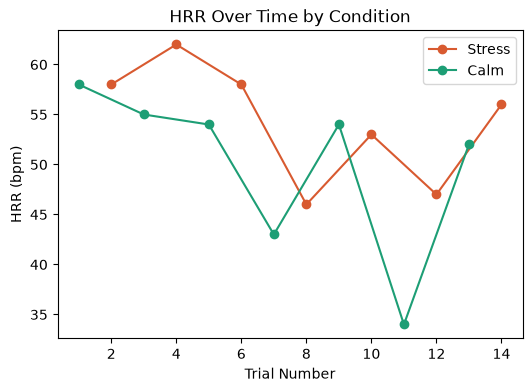

,trial_id,condition,hrr
0,1,calm,58
1,2,stress,58
2,3,calm,55
3,4,stress,62
4,5,calm,54
5,6,stress,58
6,7,calm,43
7,8,stress,46
8,9,calm,54
9,10,stress,53


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

data_path = project_root / "data" / "hrr_data.csv"
figures_folder = project_root / "figures"
figures_folder.mkdir(exist_ok=True)

df = pd.read_csv(data_path)

# Make sure trial_id and hrr are numbers
df["trial_id"] = pd.to_numeric(df["trial_id"], errors="coerce")
df["hrr"] = pd.to_numeric(df["hrr"], errors="coerce")

stress_df = df[df["condition"] == "stress"].sort_values("trial_id")
calm_df = df[df["condition"] == "calm"].sort_values("trial_id")

plt.figure(figsize=(6, 4))

plt.plot(
    stress_df["trial_id"],
    stress_df["hrr"],
    marker="o",
    color="#D85A30",
    label="Stress"
)

plt.plot(
    calm_df["trial_id"],
    calm_df["hrr"],
    marker="o",
    color="#1D9E75",
    label="Calm"
)

plt.xlabel("Trial Number")
plt.ylabel("HRR (bpm)")
plt.legend()
plt.title("HRR Over Time by Condition")

plt.savefig(figures_folder / "graph2_draft.png", dpi=150, bbox_inches="tight")

plt.show()

display(df[["trial_id", "condition", "hrr"]].sort_values("trial_id"))